# Variational Autoencoder (VAE) — Colab Notebook
_Cleaned for GitHub, with section headings and docs — generated on 2025-11-02._

This notebook implements a Variational Autoencoder (VAE) in PyTorch and is refactored for GitHub readiness:

- Clear section headings and comments
- ELBO / reconstruction + KL loss explanation
- Reproducible training loop
- Evaluation/visualization cells

> **Dataset detected:** **CIFAR10**  
> **Framework:** PyTorch + torchvision

> **Note:** The code cells and their order are preserved as-is to keep your results unchanged.

## 1. Environment & Imports

In [22]:
import torch
import torch.nn as nn
from torchvision import datasets , transforms
from torchvision.utils import make_grid
from torch.optim import Adam
from torch.utils.data import DataLoader , random_split

## 3. Data Loading

In [23]:
train_data = datasets.CIFAR10(
    root = './data' , train = True , transform = transforms.ToTensor() , download = True
)
test_data = datasets.CIFAR10(
    root = './data' , train = False , transform = transforms.ToTensor() , download = True
)

In [24]:
train_size = int(0.8 * len(train_data))
val_size = int(len(train_data) - train_size)
train_set , val_set = random_split(train_data , [train_size , val_size])

In [25]:
Train_DL = DataLoader(train_set , batch_size = 128 , shuffle = True)
Val_DL = DataLoader(val_set , batch_size = 128 , shuffle = False)
Test_DL = DataLoader(train_data , batch_size = 128 , shuffle = False)

## 8. Visualization / Reconstruction

In [26]:
import numpy as np
import matplotlib.pyplot as plt
img , _ = next(iter(Train_DL))

In [27]:
img.shape

torch.Size([128, 3, 32, 32])

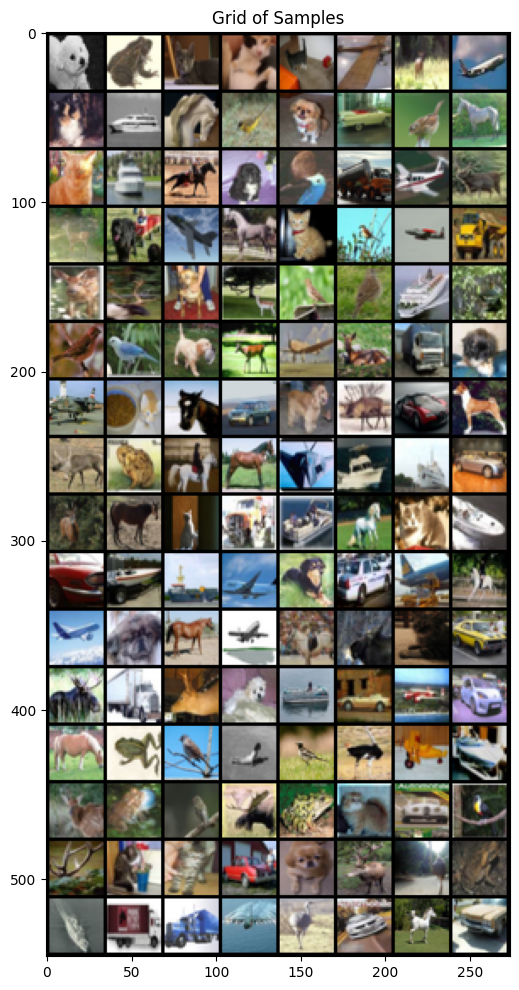

In [28]:
plt.figure(figsize = (20,12))
plt.title('Grid of Samples')
plt.imshow(np.transpose(make_grid(img),(1,2,0)))
plt.show()

## 4. VAE Model Definition

In [29]:
class VAE(nn.Module):
  def __init__(self , latent_dim = 32):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(3 , 16 , kernel_size = 3 , padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2 , stride = 2), ###32 x 32 --> 16x16
        nn.Conv2d(16 , 32 ,kernel_size = 3 , padding = 1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2 , stride = 2), ## 16 x 16 --> 8 x 8
        nn.Conv2d(32 , 64 , kernel_size = 3 , padding =1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2 , stride = 2) #8x8 --> 4x4,
    )
    self.flatten = nn.Flatten()
    hidden_dim = 64 * 4 *4
    self.mu = nn.Linear(hidden_dim , latent_dim)
    self.logvar = nn.Linear(hidden_dim , latent_dim)

    self.decode1 = nn.Linear(latent_dim , hidden_dim)

    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(64 , 32 , kernel_size = 4 , stride = 2 , padding = 1), ##nn.Upsample(scale_factor = 2 , mode = 'nearest') + conv2d(64,32,kernel_size = 3) + ReLU()
        nn.ReLU(),
        nn.ConvTranspose2d(32 , 16 , kernel_size = 4 , stride = 2 , padding = 1),
        nn.ReLU(),
        nn.ConvTranspose2d(16 , 3 , kernel_size = 4 , stride = 2 , padding = 1),
        nn.Sigmoid()
    )

  def reparameter(self ,mu , logvar):
      std = torch.exp(0.5 * logvar)
      eps = torch.randn_like(std)
      return mu +std*eps

  def forward(self, x):
      x = self.encoder(x)
      x = self.flatten(x)
      mu = self.mu(x)
      logvar = self.logvar(x)
      x = self.reparameter(mu , logvar)
      x = self.decode1(x).view(-1,64,4,4)

      logits = self.decoder(x)
      return logits , mu , logvar

## 5. ELBO / Loss

In [40]:
def elbo(x , xhat , mu , logvar):
  B = x.size(0)
  criterion = nn.MSELoss(reduction = 'sum')
  loss = criterion(x ,  xhat)/B
  kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/B
  return loss+kl

## 2. Configuration & Utilities

In [41]:
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

In [42]:
model = VAE().to(device)

## 6. Optimizer & Training Loop

In [43]:
optimizer = Adam(model.parameters() , lr = 0.001)


## 7. Validation / Evaluation

In [44]:
epochs = 20
train_loss_list = []
val_loss_list = []
for i in range(epochs):
  model.train()
  train_running_loss = 0.0
  for image , label in Train_DL:
    image = image.to(device)
    optimizer.zero_grad()

    logits , mu , logvar  = model(image)
    loss = elbo(image , logits , mu , logvar)
    loss.backward()

    train_running_loss += loss.item()
    optimizer.step()

  train_loss = train_running_loss / len(Train_DL)
  train_loss_list.append(train_loss)
  model.eval()
  with torch.no_grad():
    val_running_loss = 0.0
    for image , label in Val_DL:
      image = image.to(device)
      logits , mu , logvar = model(image)
      loss = elbo(image , logits , mu , logvar)
      val_running_loss += loss.item()

    val_loss = val_running_loss / len(Val_DL)
    val_loss_list.append(val_loss)
  print(f'Epoch : {i+1} , Train_loss :{train_loss} , Val_loss : {val_loss}')

Epoch : 1 , Train_loss :125.62395506544996 , Val_loss : 95.4848990138573
Epoch : 2 , Train_loss :90.97138813737863 , Val_loss : 86.19228218175188
Epoch : 3 , Train_loss :82.92029917659089 , Val_loss : 81.37876071205622
Epoch : 4 , Train_loss :80.50406944104277 , Val_loss : 79.74717789662036
Epoch : 5 , Train_loss :79.48095564187145 , Val_loss : 79.76868429063242
Epoch : 6 , Train_loss :78.70440508077701 , Val_loss : 78.59723016280162
Epoch : 7 , Train_loss :78.21462181505684 , Val_loss : 78.28870082806937
Epoch : 8 , Train_loss :77.80197862619028 , Val_loss : 77.99333828310424
Epoch : 9 , Train_loss :77.50187985356243 , Val_loss : 77.67162110533896
Epoch : 10 , Train_loss :77.21683806885545 , Val_loss : 77.14954057524476
Epoch : 11 , Train_loss :76.96479680362982 , Val_loss : 77.08322655400143
Epoch : 12 , Train_loss :76.7817685550775 , Val_loss : 76.8986540202853
Epoch : 13 , Train_loss :76.50052469759322 , Val_loss : 77.18078999579707
Epoch : 14 , Train_loss :76.3927265203799 , Val_l

## 9. Notes & Next Steps

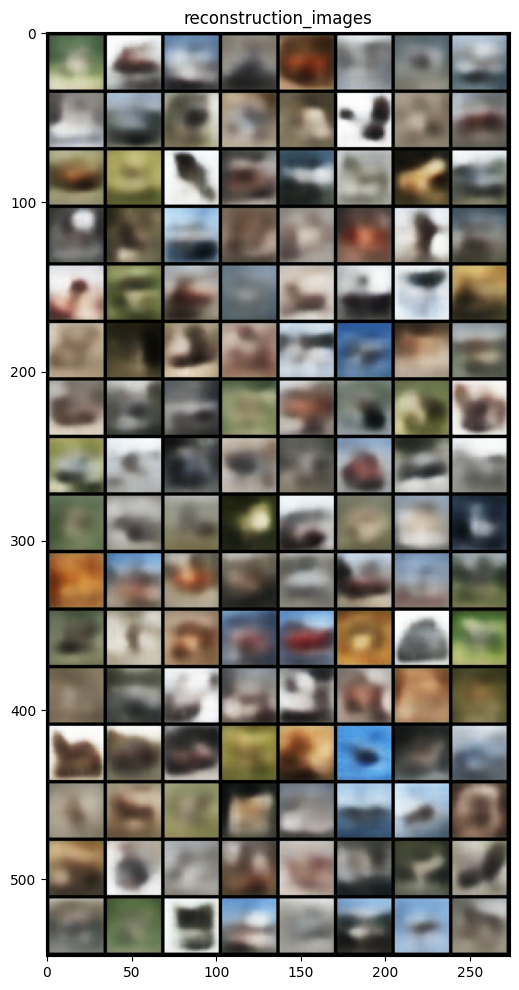

In [52]:
test_images , _ = next(iter(Val_DL))
test_images = test_images.to(device)
test_images , _ , _ = model(test_images)
with torch.no_grad():
  test_images = test_images.cpu()
  plt.figure(figsize = (20 ,12))
  plt.title('reconstruction_images')
  plt.imshow(np.transpose(make_grid(test_images),(1,2,0)))
  plt.show()


In [51]:
test_images.shape

(128, 3, 32, 32)